# exp02_xgb_base — XGBoost feature-set base (referencia)

XGBoost t+1 con el feature-set base (35 features = Fase 3). Es la **referencia** del
resto de experimentos. Este notebook ejecuta (o carga) el experimento y muestra las
evaluaciones, tablas y gráficos de forma ordenada.

Todo se apoya en `forecasting/experiments/` (framework versionado) y
`ReporteExperimento`. Para reproducir desde CLI:
`python -m forecasting.experiments.run exp02_xgb_base`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
import matplotlib.pyplot as plt
from forecasting.experiments.reporte import ReporteExperimento

# ejecutar=True fuerza recomputar; por defecto carga si ya existe.
r = ReporteExperimento.de('exp02_xgb_base', ejecutar=False)
r.resumen()

exp02_xgb_base v1 | feature-set base (35 feats) | best_iter 189
Test global: RMSE 79.82 vs persist 84.87 | skill 0.0596 | R² 0.926


## Métricas globales (val + test) — con R² y skill vs persistence

In [2]:
r.metrics_global.round(3)

,segmento,n,RMSE_persistence,RMSE_modelo,MAE_modelo,MBE_modelo,R2_persistence,R2_modelo,skill,split
0,global,4112,84.625,77.394,42.051,3.061,0.921,0.934,0.085,val
1,limpio_ff0,3712,86.679,79.166,42.725,2.213,0.912,0.927,0.087,val
2,rellenado_ff_pos,400,62.425,58.440,35.789,10.932,0.890,0.904,0.064,val
3,global,4123,84.873,79.818,46.642,1.002,0.916,0.926,0.060,test
4,limpio_ff0,3734,86.482,81.507,47.950,1.094,0.906,0.917,0.058,test
5,rellenado_ff_pos,389,67.497,61.281,34.086,0.117,0.887,0.906,0.092,test


## Métricas por régimen (test) — dónde aporta el modelo

El skill global está diluido por horas fáciles. Aquí se ve por **nubosidad** (kt) y
por **rampa** (|Δkt|) dónde el ML supera o no a persistence.

In [3]:
display(r.regimen_nubosidad.round(3))
display(r.regimen_rampa.round(3))

,regimen_nubosidad,n,RMSE_modelo,RMSE_persistence,MAE_modelo,R2_modelo,skill
0,cubierto (kt<0.3),286,144.013,135.642,104.247,-3.761,-0.062
1,parcial (0.3-0.7),708,115.353,127.541,79.734,0.528,0.096
2,despejado (kt>=0.7),3129,59.061,64.260,33.889,0.954,0.081


,regimen_rampa,n,RMSE_modelo,RMSE_persistence,MAE_modelo,R2_modelo,skill
0,rampa suave (<0.1),2818,39.311,23.286,24.840,0.981,-0.688
1,rampa moderada (0.1-0.25),817,94.104,97.163,72.176,0.862,0.031
2,rampa fuerte (>0.25),487,173.599,204.961,130.002,0.384,0.153


## Importancia de features (gain)

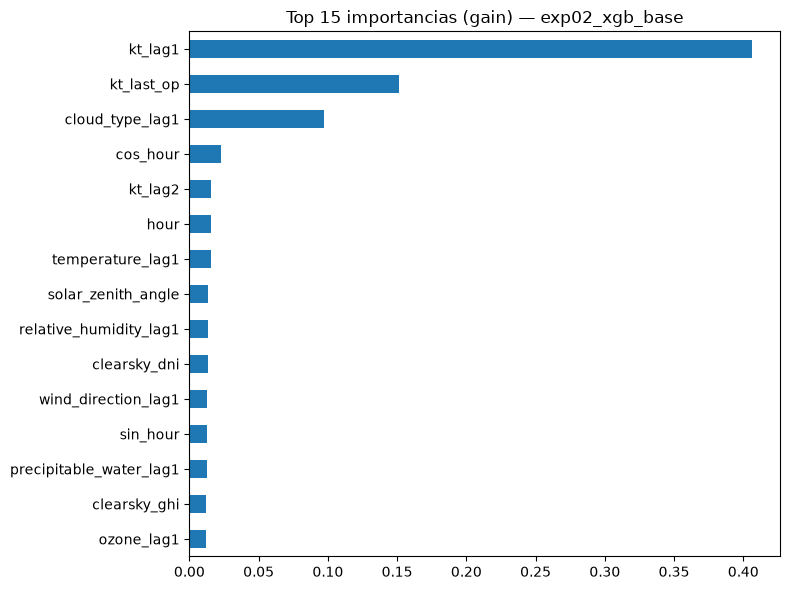

In [4]:
r.plot_importancias(15); plt.tight_layout(); plt.show()

## Series temporales: observado vs modelo vs persistence

Filtros por mes / rango / día. La línea se corta en la noche (no une días).

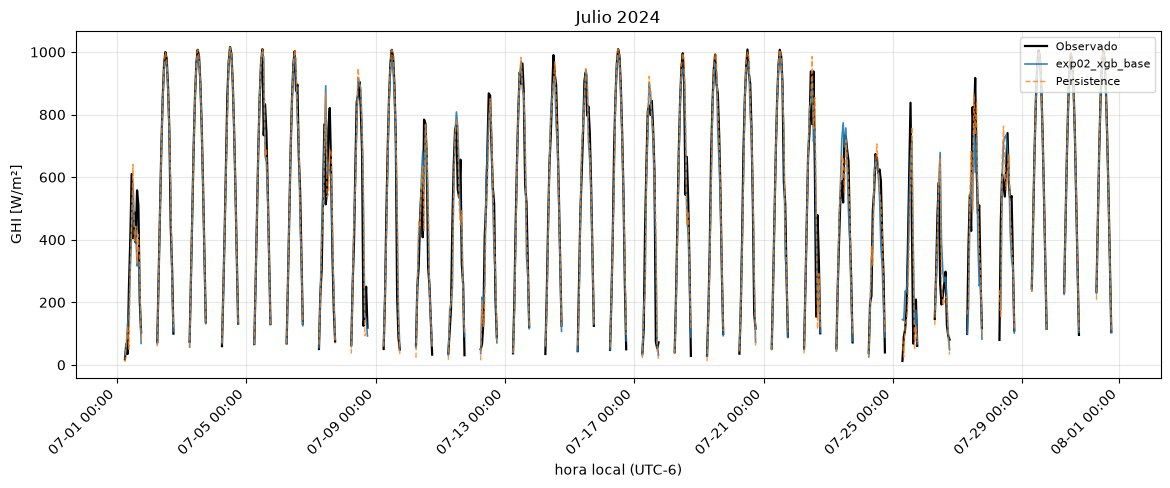

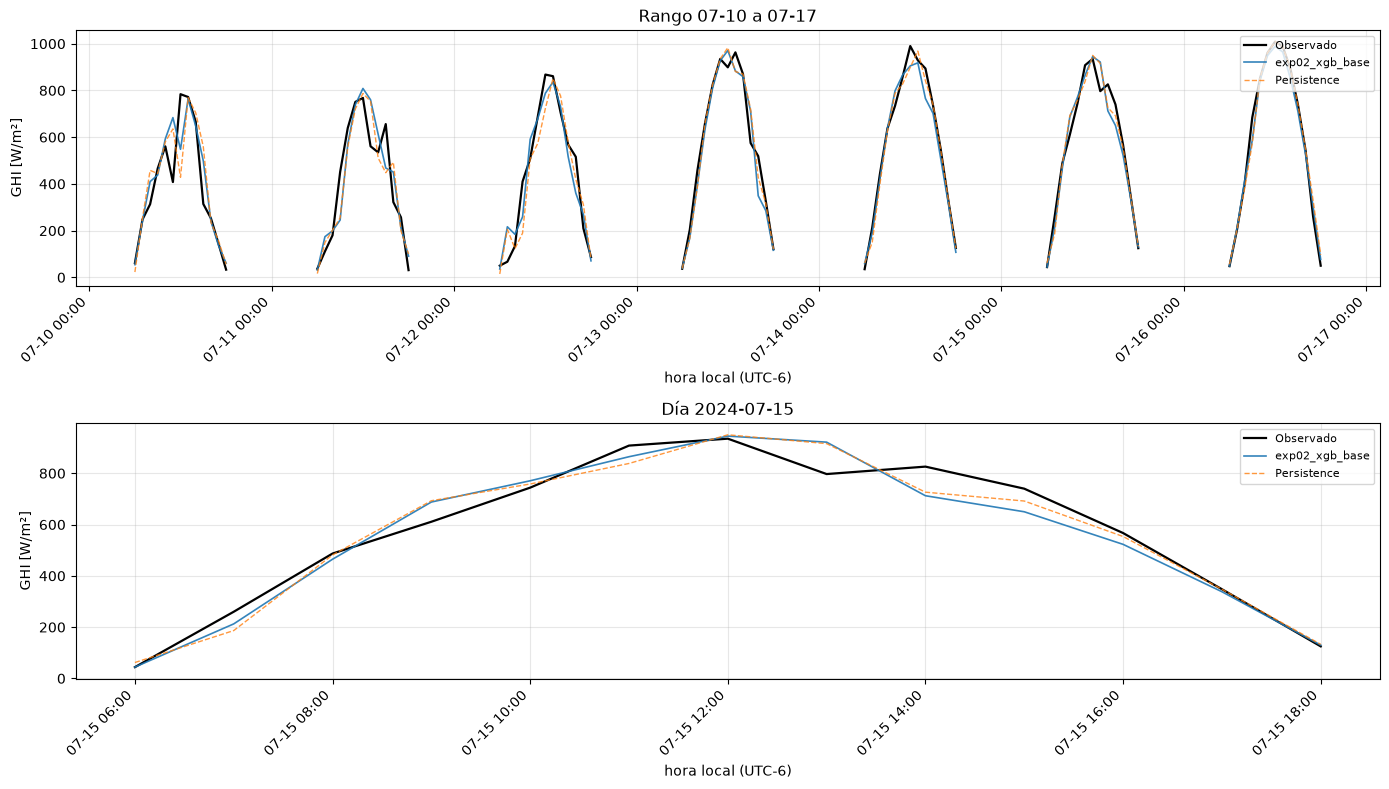

In [5]:
viz = r.visualizador()
viz.serie_temporal(mes=7); plt.title('Julio 2024'); plt.show()
fig, ax = plt.subplots(2, 1, figsize=(14, 8))
viz.serie_temporal(inicio='2024-07-10', fin='2024-07-17', ax=ax[0]); ax[0].set_title('Rango 07-10 a 07-17')
viz.serie_temporal(dia='2024-07-15', ax=ax[1]); ax[1].set_title('Día 2024-07-15')
plt.tight_layout(); plt.show()

## Dispersión predicho vs observado (con R²), coloreado por fill_flag

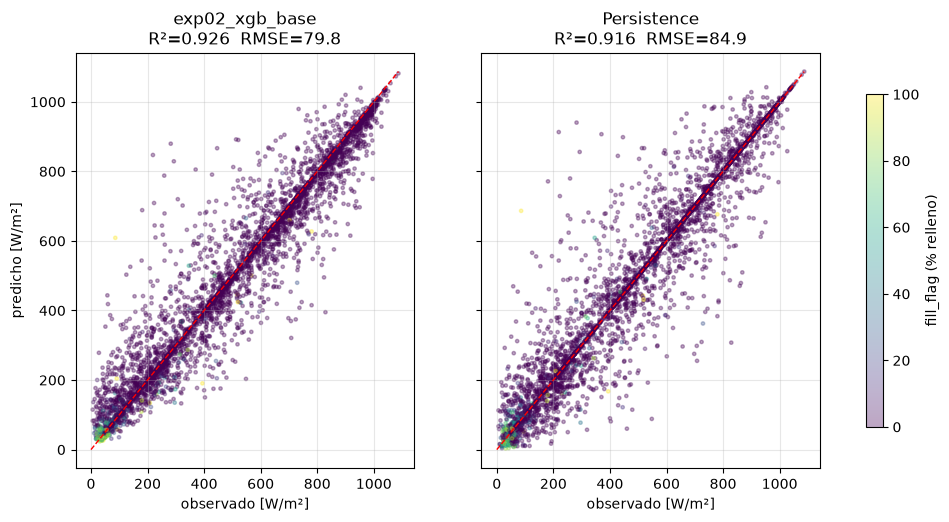

In [6]:
viz.dispersion(); plt.show()

## Días más difíciles (nublados / combinado / error real)

Días variables/nublados y con poca información, donde el modelo sufre.

,n_horas,kt_mean,kt_std,fill_frac,rmse_xgb,rmse_persist,nubosidad
dia_local,,,,,,,
2024-06-23,13,0.150,0.140,0.154,116.360,43.918,0.850
2024-02-17,10,0.174,0.096,0.100,53.130,29.522,0.826
2024-06-30,13,0.181,0.141,0.231,103.395,67.981,0.819
2024-06-22,13,0.190,0.094,0.154,81.206,61.612,0.810
2024-01-07,10,0.208,0.078,0.100,36.283,48.365,0.792
2024-02-16,10,0.226,0.090,0.000,71.979,83.443,0.774
2024-12-21,9,0.231,0.149,0.111,62.173,57.386,0.769
2024-04-22,12,0.232,0.144,0.083,73.522,53.374,0.768


,n_horas,kt_mean,kt_std,fill_frac,rmse_xgb,rmse_persist,nubosidad
dia_local,,,,,,,
2024-02-14,10,0.487,0.307,0.200,247.788,274.348,0.513
2024-10-07,11,0.682,0.260,0.182,219.766,249.998,0.318
2024-01-04,10,0.612,0.312,0.500,215.465,254.770,0.388
2024-12-25,9,0.802,0.200,0.000,185.885,206.755,0.198
2024-05-24,13,0.785,0.276,0.154,183.282,200.755,0.215
2024-08-09,12,0.732,0.335,0.083,183.275,174.793,0.268
2024-05-27,13,0.722,0.325,0.077,176.787,200.115,0.278
2024-06-04,13,0.618,0.370,0.154,175.785,197.871,0.382


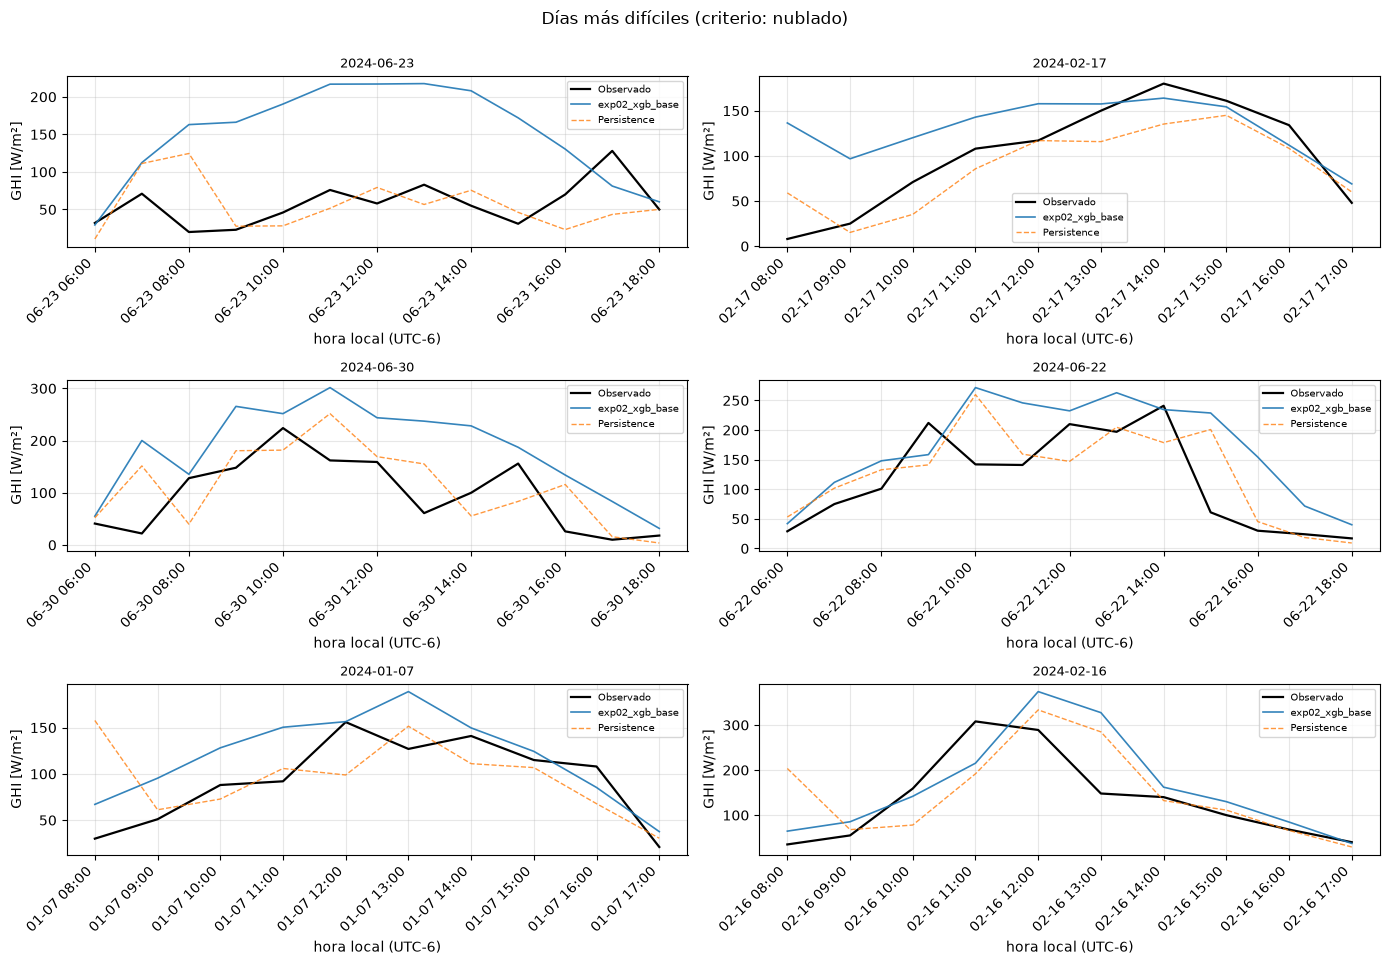

In [7]:
display(r.visualizador().dias_dificiles(n=8, criterio='nublado'))
display(r.visualizador().dias_dificiles(n=8, criterio='error_xgb'))
r.visualizador().plot_dias_dificiles(n=6, criterio='nublado'); plt.show()